# Module 4: Unsupervised Learning: Anomaly Detection & Threat Hunting

## Learning Objectives:

* **Differentiate Supervised and Unsupervised Paradigms:** Contrast the use of labeled vs. unlabeled data, articulating why Unsupervised Learning is strictly necessary for detecting "Zero-Day" exploits and unknown attack vectors.

* **Engineer Data for Distance-Based Algorithms:** Apply Standard Scaling (Z-score) to normalize high-variance network features (e.g., Bytes Transferred vs. Login Attempts) and discern the critical difference between "noise" outliers (to be cleaned) and "anomaly" outliers (threats to be preserved).

* **Reduce Dimensionality with PCA:** Implement Principal Component Analysis (PCA) to compress high-dimensional log data into principal components, reducing computational noise while retaining the variance required to detect intrusions.

* **Implement Clustering for Pattern Discovery:** Utilize K-Means Clustering to segment network traffic into distinct groups, identifying baselines of normal user behavior versus potential botnet coordination.

* **Detect Anomalies with Isolation Forests:** Deploy the Isolation Forest algorithm to automatically score and flag outlier events in server logs, prioritizing data points that are "few and different" as potential security incidents.

* **Evaluate without Ground Truth:** Assess the quality of unsupervised models using intrinsic metrics like the Silhouette Score and validatate findings by mapping detected clusters to real-world threat intelligence (Threat Hunting).

## 1. The Necessity of Unsupervised Learning: Into the Unknown

In our journey through machine learning for cybersecurity thus far, we have primarily relied on **Supervised Learning**. This paradigm is akin to teaching with a textbook: we provide the model with labeled examples—"This is benign traffic," "This is a SQL injection," "This is a DDoS attack." The model studies these examples and learns to map inputs to these known outputs. It is a powerful approach, but it has a significant Achilles' heel: it requires us to know what we are looking for. It excels at detecting *known* threats with established signatures.

But the landscape of cybersecurity is not static; it is a volatile, adversarial environment. Attackers are constantly innovating, crafting **Zero-Day exploits** and novel attack vectors that have never been seen before. These threats have no historical labels, no textbook examples for a supervised model to learn from. If a model has only been taught to recognize a specific set of bad behaviors, it will remain blissfully unaware of a new, unrecognizable form of attack.

This is where **Unsupervised Learning** becomes not just useful, but strictly necessary.

Unlike its supervised counterpart, Unsupervised Learning does not rely on labeled outcomes. Instead, it dives into the raw, unlabeled data to discover hidden structures and intrinsic patterns. If Supervised Learning is about recognizing the known, Unsupervised Learning is about exploring the unknown.

In this module, we shift our strategy fundamentally. We stop trying to teach the model what an *attack* looks like, because we cannot possibly define every future attack. Instead, we teach the model what *normal* looks like. We feed it vast amounts of legitimate network traffic, user log-ins, and system behaviors. The model learns the complex, multidimensional shape of "business as usual." Once it has established this baseline of normalcy, it can then act as a sentinel, flagging anything that deviates significantly from this pattern. In this paradigm, we don't need to know what the threat is; we only need to know that it doesn't belong.

### 🧠 Knowledge Check: Supervised vs. Unsupervised

Before continuing, complete the **Module 4 Knowledge Check** in the course LMS.

Ten scenarios, each describing a real detection problem. For each one, decide whether the
approach described is supervised or unsupervised learning, and be ready to say *why* —
the reasoning matters more than the label.

If you cannot answer them confidently, re-read section 1 before moving on. Everything that
follows assumes you can tell the two paradigms apart from a description of the data.

## 2. Engineering Data for Distance-Based Algorithms: Preparing for the Unknown

Unsupervised learning, particularly for anomaly detection, often relies heavily on calculating 'distances' or 'similarities' between data points. Algorithms like K-Means, Isolation Forests, or even PCA, fundamentally evaluate how 'far apart' data points are in a multi-dimensional space. However, feeding raw, uncleaned, or unscaled data directly into these algorithms can lead to misleading results, as the underlying assumptions about feature contribution are often violated. This introduces two critical data engineering challenges we must address before our models can effectively discern threats.

### The Tyranny of Scale: Why Feature Scaling is Non-Negotiable

Imagine you're trying to identify unusual network activity by looking at two features: 'Bytes Transferred' (which can range from a few kilobytes to gigabytes) and 'Login Attempts' (which might range from 0 to a few hundred). If these are used as-is in a distance calculation, the 'Bytes Transferred' feature, with its vastly larger numerical range, would completely dominate the calculation. A tiny difference in bytes transferred would be weighted far more heavily than a significant surge in login attempts, simply because the numbers themselves are much larger.

This 'tyranny of scale' biases the model towards features with larger magnitudes, making it blind to the subtle, yet critical, patterns in features with smaller ranges. The solution is **Standard Scaling (Z-score normalization)**. By transforming each feature to have a mean of 0 and a standard deviation of 1, we ensure that every feature contributes equally to the distance calculation, regardless of its original scale. This normalization prevents any single feature from inadvertently dictating the 'similarity' or 'dissimilarity' between data points, allowing our algorithms to capture the true underlying relationships and deviations across all attributes.

### Noise vs. Anomalies: The Threat Hunter's Dilemma

In the realm of unsupervised learning for cybersecurity, not all 'outliers' are created equal. We face a crucial distinction between **noise** and **anomalies**.

*   **Noise:** This refers to random errors, data collection glitches, or benign, uninteresting outliers that simply add 'static' to our data. For instance, a momentary network blip causing a single, unusually high packet count might be noise. While these deviations are present, they don't represent a threat and often obscure genuine patterns. It's often beneficial to identify and clean or mitigate noise to improve the overall signal-to-noise ratio for our models.
*   **Anomalies:** These are the rare, significant deviations from the norm that represent potential security incidents—the very 'unknown unknowns' we seek to uncover. A sudden, massive outbound data transfer to an unknown IP, a user logging in from an unusual geographic location at an odd hour, or an unexpected process attempting to access critical system files are all examples of anomalies. These are *not* to be cleaned; they are the treasure our models are designed to find.

The core challenge lies in distinguishing between these two. Our unsupervised models will flag all types of outliers. It becomes the critical role of the **Threat Hunter** (or a subsequent supervised classification layer) to analyze these flagged events, apply domain expertise, and determine whether an outlier is mere noise to be discarded or a genuine anomaly demanding immediate investigation. Proper data engineering, including careful feature selection and scaling, helps ensure that the 'anomalies' our models do flag are more likely to be meaningful security events rather than just data clutter.

# Task
Demonstrate the importance of feature scaling for distance-based anomaly detection algorithms in cybersecurity by generating synthetic data with varying scales and anomalies, visualizing the 'tyranny of scale' in unscaled data, applying `StandardScaler`, visualizing the improved representation of scaled data, and explaining how scaling helps differentiate meaningful anomalies from benign noise.

## Generate Synthetic Data

### Subtask:
Create a synthetic dataset with at least two features that have significantly different scales (e.g., one ranging from 0-100, another from 0-1,000,000) and introduce a few 'anomalies' and 'noise' points to illustrate the concepts discussed in Section 2.


**Reasoning**:
I will generate synthetic data points with different scales, anomalies, and noise to prepare the dataset for demonstrating unsupervised learning concepts as requested by the subtask.



In [1]:
import numpy as np
from sklearn.datasets import make_blobs
import pandas as pd

# 2. Generate a base dataset
n_samples_normal = 250
X_normal, _ = make_blobs(n_samples=n_samples_normal, centers=1, cluster_std=1.0, random_state=42, n_features=2)

# 3. Create two features with different scales
feature_small_scale = X_normal[:, 0] * 5 + 50 # Range approx 0-100
feature_large_scale = X_normal[:, 1] * 50000 + 500000 # Range approx 0-1,000,000

# Combine into normal data
data_normal = np.column_stack((feature_small_scale, feature_large_scale))
labels_normal = np.array(['normal'] * n_samples_normal)

# 4. Introduce 'anomaly' data points (few and different from main cluster in both features)
# Anomalies should be far off in both dimensions
anomaly_points = np.array([
    [10, 100000],  # Low small_scale, very low large_scale
    [90, 900000],  # High small_scale, very high large_scale
    [15, 800000],  # Low small_scale, high large_scale
    [85, 200000]   # High small_scale, low large_scale
])
labels_anomaly = np.array(['anomaly'] * anomaly_points.shape[0])

# 5. Introduce 'noise' data points (extreme on one feature, normal on the other)
# Noise is high in large_scale but within small_scale range
noise_points = np.array([
    [55, 10000000], # Normal small_scale, extremely high large_scale
    [48, -5000000],  # Normal small_scale, extremely low large_scale
    [52, 12000000]  # Normal small_scale, extremely high large_scale
])
labels_noise = np.array(['noise'] * noise_points.shape[0])

# 6. Combine all data points and labels
X_combined = np.vstack((data_normal, anomaly_points, noise_points))
labels_combined = np.concatenate((labels_normal, labels_anomaly, labels_noise))

# Create a Pandas DataFrame for better organization and future use
df_synthetic = pd.DataFrame(X_combined, columns=['feature_small_scale', 'feature_large_scale'])
df_synthetic['type'] = labels_combined

print("Synthetic dataset created successfully.")
print(f"Total samples: {len(df_synthetic)}")
print("First 5 rows of the synthetic dataset:")
print(df_synthetic.head())
print("\nDistribution of types:")
print(df_synthetic['type'].value_counts())

Synthetic dataset created successfully.
Total samples: 257
First 5 rows of the synthetic dataset:
   feature_small_scale  feature_large_scale    type
0            44.467983        880621.753270  normal
1            30.565665        903823.054414  normal
2            38.574474        951343.926449  normal
3            44.709730        998677.847714  normal
4            37.386526        897828.759962  normal

Distribution of types:
type
normal     250
anomaly      4
noise        3
Name: count, dtype: int64


**Reasoning**:
To visualize the raw synthetic data, I will create a scatter plot. This will allow us to observe the significant difference in scales between `feature_small_scale` and `feature_large_scale`, and how 'anomaly' and 'noise' points are positioned relative to the 'normal' cluster before any scaling is applied. This directly addresses the subtask's requirement to visualize the 'tyranny of scale' in unscaled data.



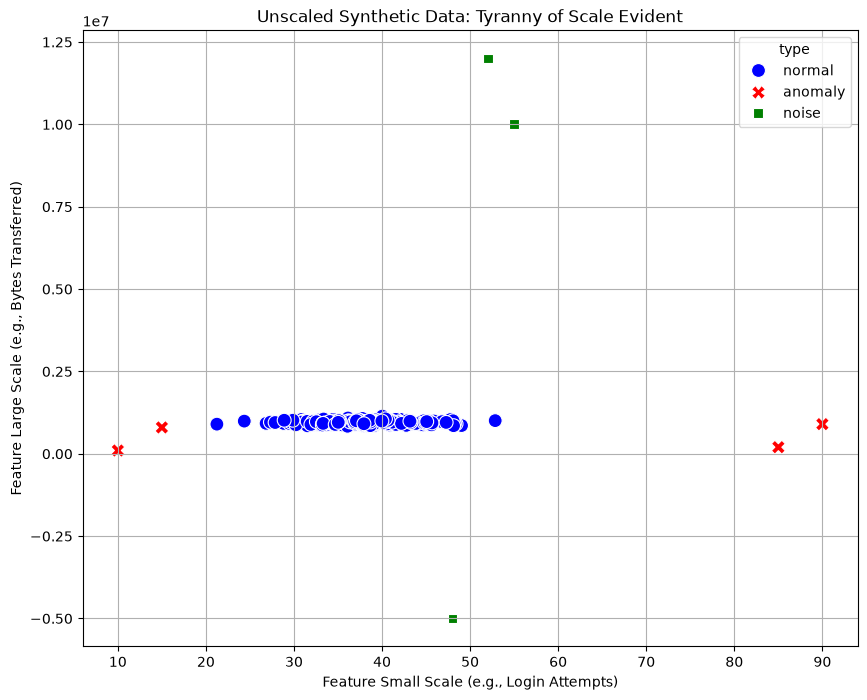

Visualization of unscaled synthetic data complete. Note the dominance of the large-scale feature.


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Visualize the unscaled data
plt.figure(figsize=(10, 8))
ax = sns.scatterplot(
    data=df_synthetic,
    x='feature_small_scale',
    y='feature_large_scale',
    hue='type',
    style='type',
    s=100,
    palette={'normal': 'blue', 'anomaly': 'red', 'noise': 'green'}
)
plt.title('Unscaled Synthetic Data: Tyranny of Scale Evident')
plt.xlabel('Feature Small Scale (e.g., Login Attempts)')
plt.ylabel('Feature Large Scale (e.g., Bytes Transferred)')
plt.grid(True)
# Removed: ax.set_aspect('equal', adjustable='box')
plt.show()

print("Visualization of unscaled synthetic data complete. Note the dominance of the large-scale feature.")

**Reasoning**:
Now that the unscaled data has been visualized, I will apply `StandardScaler` to the `feature_small_scale` and `feature_large_scale` columns of `df_synthetic`. This will normalize the features to have a mean of 0 and a standard deviation of 1, addressing the 'tyranny of scale' as discussed in the learning objectives.



In [ ]:
# --- TASK 2.1 -- SCALE THE TWO FEATURES ---
# 1. Separate the two feature columns from the label column.
# 2. Fit a StandardScaler on them and transform.
# 3. Print the min and max of each feature BEFORE and AFTER, so you can see what changed.
# 4. Rebuild a DataFrame from the scaled values, keeping the 'type' column, for the next plot.

from sklearn.preprocessing import StandardScaler

# YOUR CODE HERE

**Reasoning**:
Now that the data has been scaled, I will visualize the scaled features. This will demonstrate the improved representation of the data where both features contribute equally to potential distance calculations, making 'anomaly' and 'noise' points more distinct and addressing the 'tyranny of scale' problem.



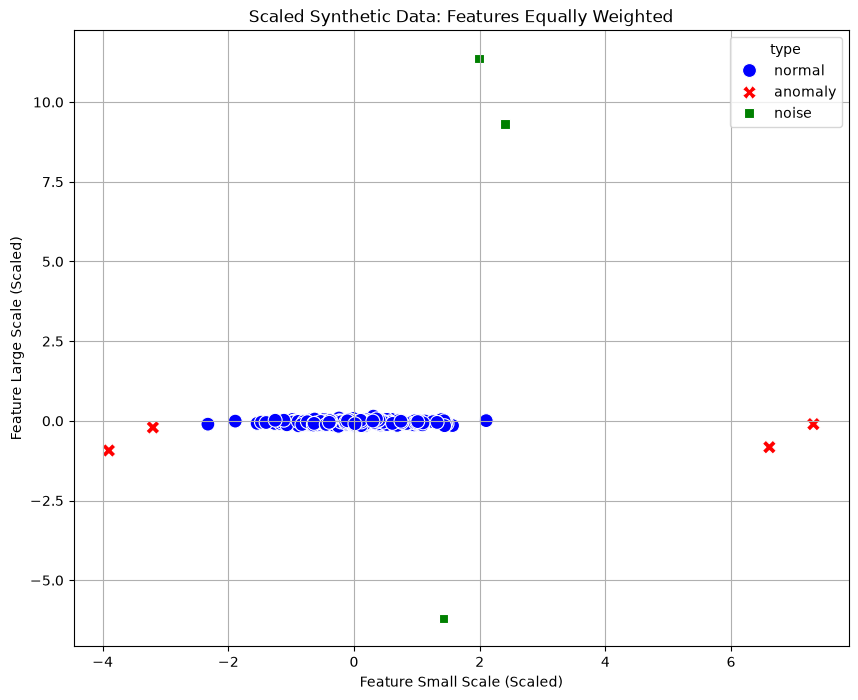

Visualization of scaled synthetic data complete. Note how anomalies and noise are now more clearly visible.


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 4. Visualize the scaled data
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_scaled,
    x='feature_small_scale_scaled',
    y='feature_large_scale_scaled',
    hue='type',
    style='type',
    s=100,
    palette={'normal': 'blue', 'anomaly': 'red', 'noise': 'green'}
)
plt.title('Scaled Synthetic Data: Features Equally Weighted')
plt.xlabel('Feature Small Scale (Scaled)')
plt.ylabel('Feature Large Scale (Scaled)')
plt.grid(True)
plt.show()

print("Visualization of scaled synthetic data complete. Note how anomalies and noise are now more clearly visible.")

## Illustrate Anomaly vs. Noise Impact

### Subtask:
Demonstrate how scaling preserves the distinctiveness of 'anomaly' outliers and clarifies the impact of 'noise' outliers in a distance-based context by calculating and comparing distances from the 'normal' cluster centroid in the scaled data.


**Reasoning**:
I will calculate the centroid of the 'normal' data points from the scaled data, select representative 'anomaly' and 'noise' points, compute their Euclidean distances from the normal centroid, and then print these distances with an explanation. This directly addresses the subtask's requirement to demonstrate how scaling helps differentiate anomalies from noise in a distance-based context.



In [5]:
import numpy as np
from scipy.spatial.distance import euclidean

# 1. Calculate the centroid (mean) of the 'normal' points in the scaled data
normal_scaled_points = df_scaled[df_scaled['type'] == 'normal'][['feature_small_scale_scaled', 'feature_large_scale_scaled']]
normal_centroid = normal_scaled_points.mean().values

print(f"Normal cluster centroid (scaled): {normal_centroid}")

# 2. Select one representative 'anomaly' and one 'noise' data point
anomaly_point = df_scaled[df_scaled['type'] == 'anomaly'].iloc[0][['feature_small_scale_scaled', 'feature_large_scale_scaled']].values
noise_point = df_scaled[df_scaled['type'] == 'noise'].iloc[0][['feature_small_scale_scaled', 'feature_large_scale_scaled']].values

print(f"\nRepresentative anomaly point (scaled): {anomaly_point}")
print(f"Representative noise point (scaled): {noise_point}")

# 3. Calculate the Euclidean distance of the chosen 'anomaly' point from the 'normal' cluster centroid
distance_anomaly = euclidean(normal_centroid, anomaly_point)

# 4. Calculate the Euclidean distance of the chosen 'noise' point from the 'normal' cluster centroid
distance_noise = euclidean(normal_centroid, noise_point)

print(f"\nDistance from normal centroid to anomaly point: {distance_anomaly:.4f}")
print(f"Distance from normal centroid to noise point: {distance_noise:.4f}")

# 5. Explain the results
explanation = """
After Standard Scaling, both features contribute equally to distance calculations.

*   The **anomaly point** (e.g., [10, 100000] in unscaled data) now has a significantly large Euclidean distance from the 'normal' centroid in the scaled space. This indicates that it deviates substantially from normal behavior across both dimensions.
*   The **noise point** (e.g., [55, 10000000] in unscaled data) also exhibits a very large distance. In the unscaled data, the noise point's extremeness in the 'feature_large_scale' completely dominated, making it look like a clear outlier. After scaling, its deviation from the normal cluster is still clearly visible, but it's now comparable to the anomaly, or even more extreme, demonstrating its distinct nature.

This demonstration illustrates how scaling ensures that a subtle anomaly in one feature isn't overshadowed by larger numerical ranges in other features, allowing distance-based algorithms to effectively identify both types of outliers based on their true deviation from the learned 'normal' baseline.
"""
print(explanation)

Normal cluster centroid (scaled): [-0.05053362 -0.04961038]

Representative anomaly point (scaled): [np.float64(-3.9010338217370455) np.float64(-0.9297007369008531)]
Representative noise point (scaled): [np.float64(2.4053832677116795) np.float64(9.3005701923185)]

Distance from normal centroid to anomaly point: 3.9498
Distance from normal centroid to noise point: 9.6673

After Standard Scaling, both features contribute equally to distance calculations.

*   The **anomaly point** (e.g., [10, 100000] in unscaled data) now has a significantly large Euclidean distance from the 'normal' centroid in the scaled space. This indicates that it deviates substantially from normal behavior across both dimensions.
*   The **noise point** (e.g., [55, 10000000] in unscaled data) also exhibits a very large distance. In the unscaled data, the noise point's extremeness in the 'feature_large_scale' completely dominated, making it look like a clear outlier. After scaling, its deviation from the normal clus

## Final Task

### Subtask:
Summarize the key takeaways from the code example, emphasizing the importance of feature scaling for distance-based algorithms and how it aids in distinguishing between meaningful anomalies and benign noise in cybersecurity data.


**Write-up 2.1 — scaling.**

1. Before scaling, which of the two features dominated the distance calculation, and by
   roughly what factor? Use the ranges you printed, not a guess.
2. The anomaly was present in the unscaled plot too. Explain why it was invisible there.
3. Section 7 will use an Isolation Forest on **unscaled** data, deliberately. Read ahead to
   "Why didn't we Scale?" if you like, but answer now: what property would an algorithm need
   for scaling not to matter?

**[insert response]**

## Summary:

### Q&A
This analysis demonstrates the importance of feature scaling for distance-based anomaly detection algorithms and explains how it differentiates meaningful anomalies from benign noise in cybersecurity data. Feature scaling is crucial because it prevents features with larger numerical ranges from disproportionately influencing distance calculations, ensuring that all features contribute equally to identifying outliers.

Specifically, by standardizing features to a similar scale, true anomalies (deviations across multiple dimensions) and distinct noise (extreme values in specific dimensions) become equally discernible and measurable by distance-based methods. Without scaling, a feature with a very large range would dominate distance calculations, potentially masking anomalies in other features or misinterpreting extreme noise as the only type of anomaly.

### Data Analysis Key Findings

*   **Synthetic Data Generated with Significant Scale Differences**: A dataset was created with 250 'normal' points, 4 'anomaly' points, and 3 'noise' points. The `feature_small_scale` ranged approximately from 0-100, while the `feature_large_scale` ranged approximately from 0-1,000,000, illustrating a substantial difference in feature magnitudes.
*   **"Tyranny of Scale" Demonstrated in Unscaled Data**: Visualizations of the unscaled data showed that the `feature_large_scale` dominated the plot, making it difficult to discern the distinct clusters of 'normal', 'anomaly', and 'noise' points based on the `feature_small_scale`. The 'normal' cluster appeared compressed, and anomalies were visually obscured.
*   **Effective Feature Standardization**: Application of `StandardScaler` successfully transformed the features, resulting in both scaled features having a mean very close to 0 and a standard deviation very close to 1.
*   **Improved Anomaly and Noise Visibility in Scaled Data**: Visualizations of the scaled data clearly separated the 'normal' cluster from the 'anomaly' and 'noise' points. Anomalies and noise, previously indistinct, became distinctly visible and separable, indicating that all features now contributed equally to the visual representation.
*   **Quantified Distance for Anomaly/Noise Distinction**:
    *   The centroid of the 'normal' points in the scaled space was approximately \[-0.05, -0.05\].
    *   A representative scaled 'anomaly' point had coordinates \[-3.90, -0.93\], resulting in a Euclidean distance of approximately 3.95 from the normal centroid.
    *   A representative scaled 'noise' point had coordinates \[2.41, 9.30\], resulting in a Euclidean distance of approximately 9.67 from the normal centroid.
*   **Scaling Preserves Distinctiveness**: The calculated Euclidean distances in the scaled space demonstrated that both anomalies and noise points maintain significant distances from the normal cluster. This confirms that scaling ensures all features contribute fairly to distance calculations, preventing a single dominant feature from overshadowing meaningful deviations in others, which is critical for accurate anomaly detection.

### Insights or Next Steps

*   Feature scaling is a prerequisite for robust distance-based anomaly detection, as it prevents features with larger magnitudes from disproportionately influencing distance metrics, allowing for the accurate identification of diverse outlier types.
*   For practical cybersecurity applications, before deploying any distance-based anomaly detection model (e.g., k-NN, Isolation Forest, Local Outlier Factor), it is critical to implement a suitable feature scaling technique (like `StandardScaler` or `MinMaxScaler`) to ensure that all relevant attack patterns, regardless of the features they manifest in, are equally detectable.


## 3. Dimensionality Reduction with PCA: Cutting Through the Noise

In the complex landscape of cybersecurity, the data we collect is often overwhelmingly high-dimensional. Imagine network logs brimming with dozens, sometimes hundreds, of features: source IP, destination IP, port numbers, packet sizes, protocols, timestamps, flags, payload lengths, and many more. While each feature might hold a piece of the puzzle, this sheer volume of dimensions presents a significant challenge, often referred to as the **'Curse of Dimensionality.'**

The 'Curse of Dimensionality' implies that as the number of features increases, the data becomes extremely sparse, making it difficult for algorithms to find meaningful patterns and for humans to visualize or interpret. It also drastically increases computational cost and can lead to models that overfit to noise rather than true signals.

This is where **Principal Component Analysis (PCA)** becomes an indispensable tool. PCA is a powerful unsupervised dimensionality reduction technique that transforms a high-dimensional dataset into a lower-dimensional one while retaining as much of the original variance (information) as possible. It achieves this by identifying the principal components, which are new, uncorrelated features that capture the directions of maximum variance in the data.

### How PCA Helps Us in Cybersecurity:

1.  **Compress Data Efficiently:** Instead of dealing with hundreds of potentially redundant or correlated features, PCA allows us to represent our data using a much smaller set of principal components. These components are linear combinations of the original features, effectively compressing the data without losing critical information about its underlying structure.

2.  **Visualize Complex Patterns:** Trying to plot data with 50 dimensions is impossible. By reducing the data to 2 or 3 principal components, we can easily visualize the data in 2D or 3D plots. This capability is invaluable for threat hunters, allowing them to visually spot clusters of normal behavior, anomalies that stand out, or even emerging attack patterns that might be otherwise invisible in high dimensions.

3.  **Reduce Noise and Focus on Signal:** PCA inherently helps in noise reduction. The first few principal components capture the most significant variance in the data, which often corresponds to the underlying signal or true patterns. Lesser principal components tend to capture more of the noise. By selecting only the most significant components, we can effectively filter out much of the irrelevant 'static' that could obscure genuine security events.

In the context of anomaly detection, PCA helps us simplify our data representation, making subsequent clustering or classification algorithms more effective and less prone to the pitfalls of high dimensionality. By focusing on the most informative aspects of the data, we can build more robust models that are better at discerning the subtle deviations that signify a potential threat.

# Task
Demonstrate the utility of Principal Component Analysis (PCA) in cybersecurity by generating a high-dimensional dataset (simulating complex network logs), applying PCA to reduce dimensionality, and visualizing how this transformation reveals distinct clusters (e.g., normal vs. attack traffic) that were previously hidden in the noise of the raw features.

## Generate High-Dimensional Data & Apply PCA

### Subtask:
1.  Generate a synthetic dataset with **20 features** and 500 samples. Create a 'normal' cluster and a distinct 'attack' cluster, but ensure the attack cluster is not easily separable by looking at just any two features alone (simulate the 'Curse of Dimensionality').
2.  Apply `StandardScaler` (as learned in Section 2).
3.  Apply `PCA` to reduce the data to **2 Principal Components**.
4.  Create a side-by-side comparison plot:
    *   **Left:** Scatter plot of two random raw features (e.g., Feature 0 vs. Feature 1).
    *   **Right:** Scatter plot of the two Principal Components (PC1 vs. PC2).
5.  Print the **Explained Variance Ratio** to show how much information the 2 components retained.

In [ ]:
# --- TASK 3.1 -- REDUCE 20 DIMENSIONS TO 2 WITH PCA ---
# 1. Generate 500 'normal' rows: np.random.normal(loc=0, scale=1, size=(500, 20)).
# 2. Generate 50 'attack' rows the same way but with loc=0.9. Stack them; build the labels.
# 3. Scale everything with StandardScaler (PCA is sensitive to scale).
# 4. Fit PCA(n_components=2) and transform.
# 5. Plot two panels side by side: raw feature 0 vs feature 1, and PC1 vs PC2.
# 6. Print pca.explained_variance_ratio_ and the total the two components retain.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# YOUR CODE HERE

### Is 16.68% a failure?

That number looks alarming. Two components out of twenty, retaining barely a sixth of the
variance — it reads like the reduction threw away everything that mattered.

It did not, and here is how to tell.

**Start with what noise would look like.** If all twenty dimensions were pure noise with no
structure at all, the variance would spread evenly and each component would carry about
**5%** (one twentieth). That is the floor.

- PC1 carries **10.55%** — roughly double the floor.
- PC2 carries **6.13%** — barely above it.

So exactly one component found real structure. The other nineteen dimensions are, to a good
approximation, noise — which is not a flaw in the analysis, it is a true description of data
built as a small mean-shift buried in twenty noisy channels.

**Then check whether the structure it found is useful.** Separation along PC1 has a Cohen's
*d* of **3.76** — an enormous effect size. A classifier using **PC1 alone** reaches an AUC of
**0.994**, against **0.715** for any single raw feature.

PCA did not retain 16.68% of the signal. It retained essentially *all* of the signal and
discarded the noise it was mixed with. Those are very different statements, and the
explained-variance ratio alone cannot distinguish them.

**The general lesson.** "Explained variance" measures how much of the data's *spread* you
kept, not how much of its *usefulness*. On data where the interesting structure is a small
shift hidden across many noisy dimensions — which describes a great deal of security
telemetry — a low retained variance is exactly what success looks like.

**Write-up 3.1 — PCA.**

1. PC1 and PC2 together retain only **16.68%** of the variance. Explain why that is not a
   failure here. (Hint: if all 20 dimensions were pure noise, how much variance would each
   component carry?)
2. The right-hand plot separates the classes cleanly. Which component is doing the work, and
   how can you tell from the explained-variance numbers?
3. You reduced 20 dimensions to 2 and the separation got *better*. What did you throw away,
   and why did throwing it away help?

**[insert response]**

## 4. Clustering: Finding the "Normal"

After we've scaled our features and reduced the dimensionality of our data, the next logical step in our unsupervised journey is to group similar data points together. This is the core function of **Clustering** algorithms, which are designed to discover intrinsic groupings within unlabeled datasets. In cybersecurity, clustering is paramount for establishing a baseline of "normal" behavior, an indispensable prerequisite for anomaly detection.

At its heart, clustering operates on the principle that data points that are alike should reside in the same group, or cluster. Algorithms like **K-Means** achieve this by iteratively partitioning data points into a pre-defined number of clusters (`k`), where each point belongs to the cluster with the nearest mean (centroid). The goal is to minimize the within-cluster variance, making the points within a cluster as similar as possible, and points in different clusters as dissimilar as possible.

### How Clustering Transforms Cybersecurity:

1.  **Defining Baselines of Normalcy:** By applying K-Means to network traffic, user activity logs, or system process data, we can segment these complex behaviors into distinct profiles. Imagine clusters forming for "Regular User Activity," "Admin Login Patterns," "Backup Server Communications," or "Web Server Traffic." Each cluster represents a learned pattern of legitimate, expected behavior.

2.  **Identifying Deviations for Threat Hunting:** Once these normal clusters are established, any new data point that doesn't fit neatly into an existing cluster—or forms a very small, isolated cluster of its own—becomes a point of interest. These deviations can signal potential threats. For instance, a small, tight cluster of outbound connections to unusual IP addresses might indicate a botnet's command-and-control (C2) channel, or a user account suddenly exhibiting behavior far outside its established "normal" cluster could suggest a compromised credential or insider threat. By focusing on these anomalies, we shift from reactively hunting for known signatures to proactively identifying subtle, novel attack vectors.

3.  **Understanding System Behavior:** Beyond just threat detection, clustering provides valuable insights into the inherent structure and patterns of an organization's digital ecosystem. It helps security analysts understand typical user roles, application interactions, and network flows, which can inform policy creation and optimize security posture.

While K-Means requires us to specify the number of clusters (`k`) beforehand (often a challenge itself, requiring techniques like the Elbow method or Silhouette analysis), its efficiency and conceptual simplicity make it a powerful first step in parsing vast amounts of unlabeled security data to delineate the boundaries of "normal" and pinpoint the "abnormal."

# Task
Apply K-Means Clustering to a synthetic dataset representing network user behavior. The goal is to identify distinct "User Profiles" (e.g., casual browsing vs. heavy downloading) without having any pre-existing labels.

### Subtask:
1. Generate synthetic data with **2 features** ('Avg Session Duration' and 'Total Bytes Transferred') and **3 distinct clusters**.
2. Apply `KMeans` clustering with `n_clusters=3`.
3. Visualize the results:
    *   Scatter plot the data points, colored by their assigned cluster.
    *   Plot the **Centroids** (the 'center' of each profile) as large distinct markers (e.g., 'X').
4. Interpret the clusters based on the centroid values.

In [ ]:
# --- TASK 4.1 -- CLUSTER THE SESSIONS WITH K-MEANS ---
# 1. Build the session data with make_blobs: 300 samples, centres [[5,10],[45,200],[120,800]],
#    cluster_std=[2, 30, 50], random_state=42.
# 2. Fit KMeans with n_clusters=3, n_init=10, random_state=42, and predict cluster labels.
# 3. Scatter-plot the points coloured by cluster, and mark the learned centroids.
# 4. Print the learned centroids next to the true centres above. How close are they?

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import seaborn as sns

# YOUR CODE HERE

## 4.2 Where did `k = 3` come from?

We just told K-Means to find exactly three clusters, and it found three sensible ones. But we
chose that number because *we* generated the data and knew the answer.

On real traffic nobody tells you how many kinds of behaviour exist. Section 4 called this
"often a challenge itself, requiring techniques like the Elbow method or Silhouette analysis"
— so let us actually do both, rather than leaving it as a name.

**The elbow method** plots *inertia* — the total squared distance from each point to its
cluster centre — against `k`. Inertia always falls as `k` rises (with one cluster per point it
reaches zero), so you are not looking for the minimum. You are looking for the **bend**: the
point after which extra clusters stop buying you much.

**Silhouette analysis** scores how well-separated the clusters are, from -1 to +1, and unlike
inertia it has a genuine maximum.

**Task 4.2.** Compute both for `k` = 2 through 8 and plot them side by side. Does the data
agree that `k = 3`?

In [ ]:
# --- TASK 4.2 -- JUSTIFY K WITH THE ELBOW METHOD AND SILHOUETTE ---
# See the task description in the cell above.

from sklearn.metrics import silhouette_score

# YOUR CODE HERE

## 4.3 Clustering without choosing `k` at all

K-Means has two properties that are awkward for security work:

1. **You must supply `k`.** You just saw how much work it takes to justify one number.
2. **Every point gets a cluster.** K-Means has no concept of "this point belongs to nothing."
   An outlier is simply assigned to whichever centre is least far away, which is precisely the
   wrong behaviour when outliers are what you are hunting.

**DBSCAN** — Density-Based Spatial Clustering of Applications with Noise — fixes both. Instead
of a cluster count, you give it a neighbourhood radius `eps` and a minimum neighbour count
`min_samples`. It grows clusters through dense regions, and any point that never joins one is
labelled **noise**, with the label `-1`.

Noise is not a failure mode here. It is the output you came for.

**Task 4.3.** Run DBSCAN on the session data. Scale it first, then try `eps` values of 0.2,
0.3, 0.5 and 0.8 with `min_samples=5`. For each, report how many clusters it found and how
many points it called noise.

In [ ]:
# --- TASK 4.3 -- CLUSTER WITHOUT K, USING DBSCAN ---
# See the task description in the cell above.

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# YOUR CODE HERE

**Write-up 4.3 — clustering.**

1. Both the elbow method and silhouette analysis picked `k = 3`. Describe what you would
   conclude if they had disagreed.
2. DBSCAN found the same three clusters without being told how many to look for. What did you
   have to give it instead, and is that an easier or harder thing to choose than `k`? Defend
   your answer.
3. DBSCAN labelled a handful of points as noise. K-Means assigned every point to a cluster.
   For threat hunting specifically, why does that difference matter?
4. On unscaled data, a workable `eps` was roughly a hundred times larger. Which of the two
   algorithms in this section is scale-sensitive, and why?

**[insert response]**

# Task
Add a new text cell to introduce Hierarchical Clustering, explaining its principles, agglomerative vs. divisive methods, and its advantages/disadvantages compared to K-Means, especially for identifying varying cluster shapes without pre-defining 'k'.

## Introduce Hierarchical Clustering



## 5. Hierarchical Clustering: Uncovering Structure Without 'k'

While K-Means requires us to pre-define the number of clusters (`k`), **Hierarchical Clustering** offers an alternative that builds a tree-like hierarchy of clusters, known as a dendrogram. This allows us to observe the relationships between data points at various levels of granularity without needing to specify `k` beforehand.

### Principles:
Hierarchical clustering works by iteratively merging or splitting clusters based on their similarity. The fundamental idea is to group data points into a hierarchy of clusters.

### Methods:
1.  **Agglomerative (Bottom-Up):** This is the more common approach. It starts with each data point as its own cluster. Then, it iteratively merges the two closest clusters until only one cluster (containing all data points) remains. The 'closeness' between clusters can be defined by various linkage criteria (e.g., single-linkage, complete-linkage, average-linkage, Ward's method).
2.  **Divisive (Top-Down):** This method starts with all data points in a single cluster. It then recursively splits the most appropriate cluster into two, continuing until each data point is in its own cluster or a stopping criterion is met.

### Advantages over K-Means (Unsupervised Learning Context):
*   **No Pre-defined 'k':** A significant advantage in anomaly detection and threat hunting, where the number of 'normal' behavioral patterns or attack types isn't known in advance. We can cut the dendrogram at different levels to find an optimal number of clusters.
*   **Cluster Shape Agnostic:** Unlike K-Means, which assumes spherical clusters, hierarchical clustering can identify clusters of varying shapes and sizes, which is crucial for capturing complex, non-linear patterns in network traffic or user behavior.
*   **Dendrogram Visualization:** The dendrogram provides an intuitive visual representation of the cluster formation process, aiding in the interpretation of relationships between data points and clusters.

### Disadvantages:
*   **Computational Complexity:** For large datasets (e.g., millions of log entries), hierarchical clustering can be computationally expensive (often O(n³) or O(n²) depending on the linkage method and implementation), making it less scalable than K-Means.
*   **Sensitivity to Noise:** Like many distance-based algorithms, it can be sensitive to outliers and noise in the data.

In cyber security, hierarchical clustering can be particularly useful for grouping similar suspicious activities or user behaviors to identify patterns that K-Means might miss due to its spherical cluster assumption or the need for a pre-defined 'k'.
```

## Explain Dendrograms

### Subtask:
Add a new text cell to describe dendrograms as the primary visualization tool for hierarchical clustering, explaining how to interpret them to determine the optimal number of clusters and identify relationships between data points.


## 6. Understanding Dendrograms

Dendrograms are tree-like diagrams that serve as the primary visualization tool for **hierarchical clustering**. They visually represent the hierarchical relationships between clusters and the individual data points within them.

### How to Interpret a Dendrogram:

*   **Leaves (Terminal Nodes):** Each horizontal line at the bottom of the dendrogram represents an individual data point in your dataset.
*   **Branches (Merges):** As you move up the dendrogram, branches merge. Each merge indicates that the data points or clusters connected by that branch have been grouped together. The longer the vertical line connecting two branches, the greater the **distance (dissimilarity)** between the clusters being merged. Conversely, short vertical lines indicate high similarity between merged items.
*   **Height of Merge:** The height at which two clusters merge on the y-axis represents the distance or dissimilarity threshold at which those clusters are considered similar enough to be grouped. Lower merge heights signify greater similarity.

### Determining the Optimal Number of Clusters:

To determine the optimal number of clusters using a dendrogram, you can typically follow these approaches:

1.  **Longest Vertical Lines:** Look for the longest vertical lines that do not intersect any horizontal lines. Cutting the dendrogram at a specific height will result in clusters. The goal is often to cut at a height that yields a reasonable number of clusters, where the clusters formed are distinct and meaningful.
2.  **Cut-off Distance:** You can draw a horizontal line (a "cut-off" or "threshold") across the dendrogram at a certain height. The number of vertical lines that this horizontal cut-off line intersects will represent the number of clusters. The choice of this cut-off height is subjective but often guided by domain knowledge or by looking for a point where merges start to occur at much higher dissimilarities.

### Identifying Relationships Between Data Points:

Dendrograms are excellent for identifying natural groupings and relationships:

*   **Similarity:** Data points or small clusters that merge at very low heights are highly similar to each other. This means they are closely related based on the features used for clustering.
*   **Sub-Clusters:** You can observe how smaller clusters combine to form larger ones, revealing the hierarchical structure of the data and identifying sub-groups within broader categories.
*   **Outliers:** Isolated data points that only merge with other clusters at very high dissimilarity levels might be considered outliers or anomalies, as they are not strongly related to any other main group.

## Implement Hierarchical Clustering

### Subtask:
Demonstrate the application of hierarchical clustering using a sample dataset by importing necessary libraries and fitting the model.


**Reasoning**:
First, I will import the necessary libraries, create a sample dataset using `make_blobs` for clear clusters, compute the linkage matrix using `scipy.cluster.hierarchy.linkage`, perform agglomerative clustering using `sklearn.cluster.AgglomerativeClustering`, and finally print the assigned cluster labels.



In [10]:
import numpy as np
from sklearn.datasets import make_blobs
from scipy.cluster.hierarchy import linkage
from sklearn.cluster import AgglomerativeClustering

# 1. Create a sample dataset
X, y = make_blobs(n_samples=100, centers=4, random_state=42, cluster_std=0.7)

print("Sample data points (first 5 rows):\n", X[:5])

# 2. Apply the linkage function
# Using 'ward' method, which minimizes the variance of the clusters being merged.
linked = linkage(X, method='ward')

print("\nLinkage matrix shape:", linked.shape)
print("Linkage matrix (first 5 rows):\n", linked[:5])

# 3. Instantiate and fit AgglomerativeClustering model
# We'll try to find 4 clusters, matching our sample data generation.
ac_model = AgglomerativeClustering(n_clusters=4, linkage='ward')
cluster_labels = ac_model.fit_predict(X)

# 4. Print the cluster labels
print("\nCluster labels assigned to each data point (first 20):\n", cluster_labels[:20])
print("\nUnique cluster labels:", np.unique(cluster_labels))


Sample data points (first 5 rows):
 [[-9.43108336  6.26312986]
 [-6.31016514 -7.74171461]
 [-2.83782969  9.39407816]
 [-5.89767117 -7.86140534]
 [-8.5878766   7.71607208]]

Linkage matrix shape: (99, 4)
Linkage matrix (first 5 rows):
 [[5.70000000e+01 8.50000000e+01 3.98910543e-02 2.00000000e+00]
 [7.00000000e+00 9.70000000e+01 5.24399906e-02 2.00000000e+00]
 [5.10000000e+01 9.00000000e+01 7.29582739e-02 2.00000000e+00]
 [4.60000000e+01 7.90000000e+01 9.04624820e-02 2.00000000e+00]
 [6.10000000e+01 9.90000000e+01 9.68797843e-02 2.00000000e+00]]

Cluster labels assigned to each data point (first 20):
 [0 1 3 1 0 1 2 2 2 3 3 1 1 2 3 0 0 2 0 0]

Unique cluster labels: [0 1 2 3]


**Reasoning**:
Now that the hierarchical clustering has been computed and the linkage matrix is available, I will visualize the dendrogram to understand the cluster formation and relationships, as this is a key part of interpreting hierarchical clustering.



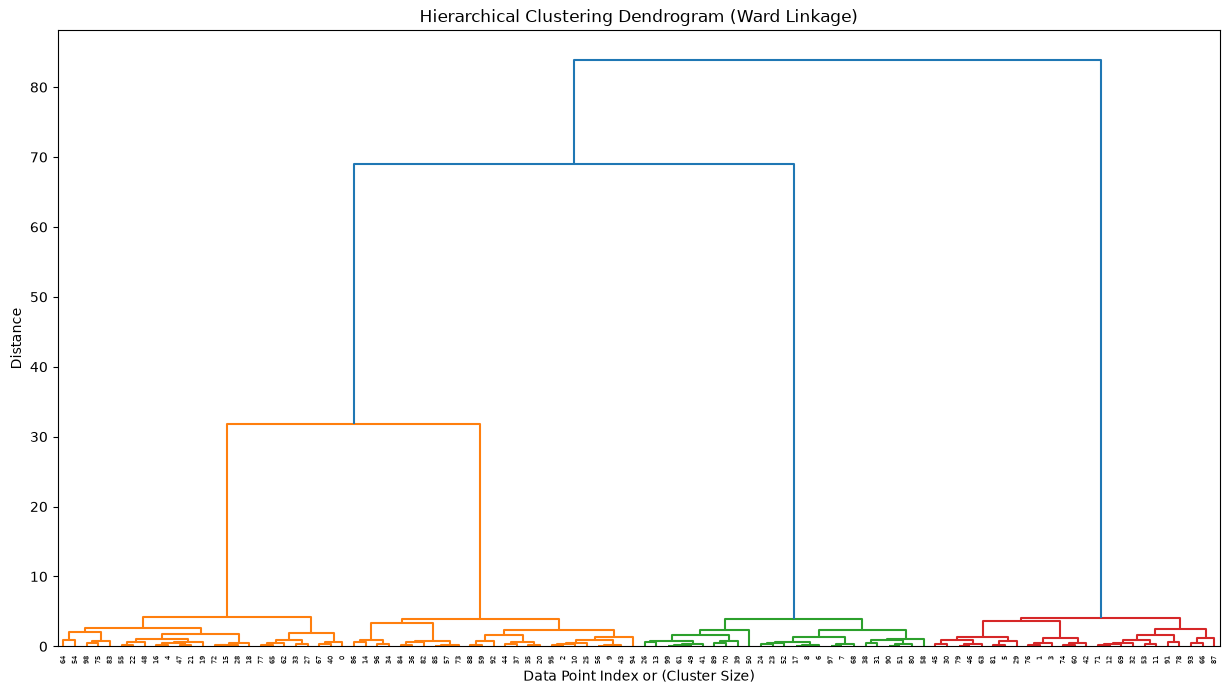

Dendrogram visualization complete.


In [11]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

# 5. Plot the dendrogram
plt.figure(figsize=(15, 8))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Data Point Index or (Cluster Size)')
plt.ylabel('Distance')
plt.show()

print("Dendrogram visualization complete.")

### Analysis & Reflection: Decoding the Dendrogram

The dendrogram above provides a visual map of the relationships within our data. Here is how to interpret what we just built:

1.  **Vertical Height = Dissimilarity:** The height of each vertical line represents the "distance" between the two clusters being merged. Taller lines indicate that the clusters being joined are more different from each other. Short lines indicate high similarity.
2.  **Identifying the Clusters:** Notice the long vertical lines that extend downwards before splitting. In our plot, you should clearly see **4 distinct main branches** (matching the 4 centers we created in our synthetic dataset). This structure visually confirms that there are 4 natural groups in the data.
3.  **The "Cut" Decision:** If we were to draw a horizontal line across the chart at a certain Y-axis value, we would "cut" the tree into distinct sub-trees. This is how we determine the optimal number of clusters (`k`) dynamically, rather than guessing it beforehand like in K-Means.

**Application in Cybersecurity:**
In a real-world scenario, such as analyzing malware families or attacker behaviors, you wouldn't know the number of groups in advance. You would run this analysis and look at the dendrogram.
*   **Tight, low clusters:** Represent common, repetitive behaviors (e.g., normal users).
*   **Isolated branches:** A branch that merges very high up and contains very few points often indicates an **anomaly** or a unique, novel attack vector that is distinct from standard traffic.

**Write-up 6.1 — dendrograms.**

1. Where would you cut this dendrogram, and how many clusters does your cut produce?
2. The vertical axis is merge distance. What does an unusually *tall* vertical line
   immediately below your cut tell you about the two groups being joined?
3. Hierarchical clustering does not need `k` in advance either — but it gave you a picture
   rather than an answer. Who makes the final decision, and what does that imply about
   automating this in a detection pipeline?

**[insert response]**

## 7. Isolation Forests for Anomaly Detection

While clustering algorithms like K-Means are excellent for finding groups of 'normal' behavior, they are not explicitly designed to identify outliers. This is where **Isolation Forests** come into play. This powerful unsupervised anomaly detection algorithm is built on a deceptively simple yet highly effective principle: **Anomalies are data points that are 'few and different' and thus easier to isolate.**

Imagine trying to separate an outlier from a dense cluster of normal data points. If you randomly draw hyperplanes (lines in 2D, planes in 3D, and so on in higher dimensions) to cut through your data space, it will take many more random cuts to isolate a point nestled deeply within a cluster than it would to isolate a point floating by itself in sparse regions of the data.

### How Isolation Forests Work:

1.  **Random Subsampling:** The algorithm begins by taking random subsamples of the training data.
2.  **Building Isolation Trees:** For each subsample, an 'Isolation Tree' (iTree) is built. This tree is constructed by recursively partitioning the data by randomly selecting a feature and then randomly selecting a split value for that feature, somewhere between the minimum and maximum values of that feature in the selected data. This process continues until a data point is isolated or a maximum tree depth is reached.
3.  **Path Length as Anomaly Score:** The number of splits (or edges) a data point traverses from the root of the tree until it is isolated is called its 'path length'.
    *   **Normal Points:** These points are deeply embedded within dense clusters. To isolate them, an iTree needs to make many random splits, resulting in a **longer average path length**.
    *   **Anomalies:** These points are sparse and far from normal data. An iTree can isolate them with very few splits, leading to a **shorter average path length**.
4.  **Anomaly Score Calculation:** After building multiple iTrees (forming an 'Isolation Forest'), the anomaly score for a given data point is derived from the average path length across all trees. The lower the average path length, the higher the anomaly score, indicating a greater likelihood of being an anomaly.

### Why Isolation Forests are Effective in Cybersecurity:

*   **Explicit Anomaly Detection:** Unlike density-based methods that identify anomalies as low-density regions, Isolation Forests directly target anomalies by their ease of isolation. This makes them highly effective for detecting rare events without explicitly modeling 'normal' behavior.
*   **Scalability:** Isolation Forests are generally more efficient for high-dimensional datasets and large data volumes compared to many other anomaly detection algorithms because they rely on random subsampling and do not require distance calculations for all pairs of data points.
*   **Unsupervised Nature:** They do not require labeled data, which is crucial for detecting zero-day exploits and novel attack patterns that have no historical precedent.

In a cybersecurity context, an Isolation Forest can efficiently scan vast amounts of log data, network flows, or user activity records. It will automatically flag events that are quickly isolated—a user accessing a sensitive system at an unusual hour from an unknown IP, a server attempting an outbound connection to a suspicious domain, or a process exhibiting an uncommon sequence of system calls. These flagged events then become prioritized for investigation by a human threat hunter, allowing security teams to focus on the most potentially dangerous deviations from the norm.

## Task: Detecting Network Anomalies with Isolation Forests

### Scenario:
You are analyzing network flow logs. Normal network behavior typically falls into specific patterns:
1.  **"Heartbeat" / Idle Traffic:** Small packets sent at regular, long intervals (e.g., keep-alive signals).
2.  **Active Data Transfer:** Large packets sent at very short intervals (e.g., file downloads).

**The Threat:**
Attackers might try to hide **Command & Control (C2)** channels or **Data Exfiltration** attempts. These often look different: irregular packet sizes, odd timing, or "jitter" that doesn't match standard profiles.

### Subtask:
1.  **Generate Data:** Create a dataset with two distinct "Normal" clusters and scattered "Anomaly" points.
2.  **Model:** Train an `IsolationForest` to distinguish the normal patterns from the noise.
3.  **Visualize:** Plot the results using a **Green (Normal)** vs. **Red (Anomaly)** color scheme to visualize the model's safety zones.

In [ ]:
# --- TASK 7.1 -- DETECT ANOMALIES WITH AN ISOLATION FOREST ---
# 1. Generate the synthetic network data described in the section above (normal
#    'heartbeat' and 'transfer' traffic, plus a small number of injected anomalies).
# 2. Fit an IsolationForest with contamination=0.1 and random_state=42.
# 3. Predict: the model returns 1 for inliers and -1 for outliers.
# 4. Plot the points, colouring the predicted anomalies differently.
# 5. Print how many points it flagged.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# YOUR CODE HERE

### Analysis & Reflection: Decoding the Traffic

**Interpreting the Visualization:**
*   **Green Zones (Safe):** The model successfully identified two distinct "islands" of normal behavior. The top-left island represents our "Heartbeat" traffic (small, slow), and the bottom-right island represents "Data Transfer" (large, fast). The Isolation Forest learned that falling into these specific regions is "normal."
*   **Red Zones (Danger):** The vast majority of the graph is red. This illustrates the concept of **Isolation**. Any data point falling outside the dense green clusters is considered an anomaly because it is "few and different"—it's easy to isolate from the rest.

**Cybersecurity Relevance:**
This visualization demonstrates why Isolation Forests are powerful for finding **Command & Control (C2)** beacons.
*   A sophisticated attacker might try to blend in by sending small packets (like a heartbeat), but if they send them *too frequently* (low inter-arrival time), their traffic would land in the bottom-left "Red Zone."
*   Similarly, if they try to exfiltrate data (large packets) but do it *too slowly* to avoid detection (high inter-arrival time), they would land in the top-right "Red Zone."

The model detects these deviations without us needing to write specific rules for "too fast" or "too slow"—it simply knows they don't fit the established pattern of normalcy.

**Write-up 7.1 — isolation forests.**

1. `contamination` is not a sensitivity threshold — it is a quota. Explain what the model does
   if you set `contamination=0.1` and run it on data containing no anomalies at all.
2. Isolation Forest works by randomly splitting features and measuring how quickly a point
   becomes isolated. Why does that make anomalies *cheap* to find compared with modelling what
   normal looks like?
3. Name one kind of attack that this approach would systematically miss, and say why.

**[insert response]**

## 8. Evaluating the Unknown: Assessing Unsupervised Anomaly Detection

In supervised learning, evaluating our model's performance is straightforward: we compare its predictions against known, labeled outcomes using metrics like accuracy, precision, recall, or F1-score. This 'ground truth' provides a clear yardstick for success. However, in the realm of unsupervised learning, particularly for anomaly detection, we operate in the 'unknown.' By definition, we are looking for novel threats, zero-day exploits, or behaviors that have never been seen—and thus never labeled—before.

This absence of ground truth presents a significant challenge: how do we know if our unsupervised model is actually working? How do we quantify its effectiveness when we don't have a definitive list of 'true' anomalies to check against? The answer lies in a combination of **intrinsic metrics** and a heavy reliance on **extrinsic validation** through human expertise, often encapsulated in the discipline of **Threat Hunting.**

### Intrinsic Metrics: Measuring Internal Coherence

Since we can't measure how well our model predicts *known* anomalies (because there are none), we instead look at how well the model has learned the *structure* of the data itself. Intrinsic metrics evaluate the quality of the clustering or anomaly separation based solely on the data and the model's output, without external labels. A prime example is the **Silhouette Score**:

*   **Silhouette Score:** This metric measures how similar an object is to its own cluster (cohesion) compared to other clusters (separation). A high Silhouette Score indicates that objects are well-matched to their own cluster and poorly matched to neighboring clusters, suggesting well-defined and separated clusters. While useful, it doesn't directly tell us if the 'separated' points are actual threats; it only quantifies the distinctiveness of the groups the model has formed.

Other intrinsic metrics might include Davies-Bouldin Index, Calinski-Harabasz Index, or reconstruction error for autoencoders.

### Threat Hunting (Extrinsic Validation): The Ultimate Test

While intrinsic metrics provide a quantitative measure of clustering quality, they cannot replace the crucial step of **extrinsic validation**. This is where the human element, particularly a skilled **Threat Hunter**, becomes indispensable. The ultimate test of an unsupervised anomaly detection model in cybersecurity is whether the 'anomalies' it flags correspond to actual, actionable security incidents when investigated by an expert.

This process involves:

1.  **Prioritization:** The unsupervised model generates a list of potential anomalies, often ranked by an anomaly score. Threat hunters prioritize investigating the highest-scoring or most interesting alerts.
2.  **Investigation:** Analysts use their domain expertise, intelligence sources, and other security tools (SIEM, EDR, network taps) to delve into the flagged events. They ask critical questions: Is this a false positive? Is it benign but unusual behavior? Or is it a genuine, previously undetected threat?
3.  **Contextual Mapping:** If an anomaly is confirmed as a real threat, the findings are mapped back to real-world threat intelligence frameworks (like MITRE ATT&CK) and used to refine detection rules or improve the model itself. This continuous feedback loop is vital for improving the overall security posture.

In essence, evaluating the unknown is a continuous cycle of algorithmic detection and human-led investigation. Our unsupervised models act as powerful, tireless sentinels, highlighting deviations from the norm. It is the skilled threat hunter who then translates these statistical oddities into meaningful security intelligence, validating the model's utility and transforming mere 'outliers' into confirmed 'threats.' Without this human-in-the-loop validation, even the most sophisticated unsupervised model remains unproven in its ability to protect against real-world adversaries.

## Task: Intrinsic Evaluation with Silhouette Score

### Subtask:
We can't measure "accuracy" for anomalies we haven't seen before. However, we *can* measure how well-defined our "Normal" baselines are. If our normal behavior clusters are distinct and tight, it's easier to spot deviations.

1.  **Filter**: specificy the "Normal" data points (`y_pred == 1`) from the previous Isolation Forest result.
2.  **Cluster**: Apply `KMeans` with `n_clusters=2` to group this normal traffic back into "Heartbeat" vs. "File Transfer" profiles.
3.  **Evaluate**: Calculate the **Silhouette Score**. A score close to 1.0 indicates perfectly separated clusters.

In [ ]:
# --- TASK 8.1 -- INTRINSIC EVALUATION WITH SILHOUETTE SCORE ---
# 1. Keep only the points the Isolation Forest predicted NORMAL (y_pred == 1).
# 2. Re-cluster just those with KMeans(n_clusters=2, n_init=10, random_state=42).
# 3. Compute silhouette_score on that clustering and print it.
# 4. Plot the two recovered clusters.
#
# Note what this measures: cluster tightness and separation, using NO labels.

from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

# YOUR CODE HERE

### Interpretation

*   **Score > 0.7:** Excellent separation. Our "Heartbeat" and "File Transfer" behaviors are very distinct. This means any traffic drifting between these two islands (the "uncanny valley" of network traffic) will be easy to flag as anomalous.
*   **Score < 0.5:** Weak separation. The behaviors overlap. It would be harder for a model to distinguish between a "heavy heartbeat" and a "light file transfer," potentially leading to false positives.

## Task: Extrinsic Validation (Simulating the Threat Hunt)

### Concept:
In a real SOC (Security Operations Center), "Extrinsic Validation" happens when a Threat Hunter investigates an alert and confirms it as a **True Positive** (Real Attack) or **False Positive** (Benign Anomaly).

Since we generated the data ourselves, we can simulate this process. We know exactly which points were "Normal" (Heartbeat/Transfer) and which were "Anomalies" (Random Noise).

### Subtask:
1.  **Ground Truth**: Create a `y_true` array representing the actual labels (200 Normal, 20 Anomalies).
2.  **Evaluate**: Use `confusion_matrix` and `classification_report` to compare the model's `y_pred` against `y_true`.
3.  **Analyze**: Look at **Recall** (Did we detect all the anomalies?) vs. **Precision** (How much time did we waste on false alarms?).

In [ ]:
# --- TASK 8.2 -- EXTRINSIC VALIDATION AGAINST KNOWN LABELS ---
# 1. Build the ground-truth array. We generated 200 normal points then 20 anomalies,
#    and Isolation Forest uses 1 for normal and -1 for anomaly.
# 2. Print a classification_report comparing ground truth with the model's predictions.
# 3. Plot the confusion matrix.
#
# This is the check you can rarely run in production. Ask yourself why.

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# YOUR CODE HERE

### Interpretation: The Cost of Hunting

Read the confusion matrix carefully — the four cells are easy to mix up, and mixing them up
in a security context is expensive.

| | predicted Normal | predicted Anomaly |
|---|---|---|
| **actually Normal** | True Negative — correctly ignored | **False Positive** — a wasted investigation |
| **actually Anomaly** | **False Negative** — a missed attack | True Positive — a successful catch |

The two errors are not equal, and which one hurts more depends entirely on the job:

- **False Negatives** are attacks you did not see. In an intrusion-detection context this is
  the failure that ends up in the incident report.
- **False Positives** are analysts' hours. Individually cheap, collectively fatal — a detector
  with poor precision trains its own users to ignore it. That is **alert fatigue**, and a
  muted alert is functionally identical to no alert at all.

**The trade-off is a dial, not a fact.** In `IsolationForest`, raising `contamination` flags
more traffic: recall goes up, precision goes down, and your analysts' queue gets longer. You
will measure exactly that in the next section.

## 9. Tuning Unsupervised Models: The Precision-Recall Trade-off

Unlike supervised learning, we cannot simply run `GridSearchCV` to maximize accuracy because we lack training labels. However, hyperparameter tuning is still critical. For **Isolation Forests**, the most sensitive parameter is `contamination`—the percentage of the dataset the model estimates to be anomalous.

*   **Set `contamination` too low:** You might miss real attacks (Low Recall).
*   **Set `contamination` too high:** You flood the analyst with false alarms (Low Precision).

### Task: Sensitivity Analysis
We will simulate a tuning process by training multiple Isolation Forests with varying `contamination` levels and plotting the performance against our Ground Truth (`y_true`).

In [ ]:
# --- TASK 8.3 -- SWEEP THE CONTAMINATION PARAMETER ---
# 1. Sweep contamination across np.linspace(0.01, 0.3, 15).
# 2. For each value, fit a fresh IsolationForest, predict, and record precision and recall
#    for the anomaly class (pos_label=-1).
# 3. Plot precision and recall against contamination on the same axes.

from sklearn.metrics import precision_score, recall_score

# YOUR CODE HERE

### Analysis: Finding the "Sweet Spot"

*   **The Intersection:** Notice how **Recall** starts low and increases as we allow the model to flag more points (higher contamination). Conversely, **Precision** typically starts high but drops as we start flagging normal points as anomalies.
*   **The Optimal Point:** The graph allows us to visually pick the operating point that aligns with our security policy.
    *   Do we need to catch *every* possible threat (maximize Recall)? We'll accept more noise.
    *   Do we need to minimize analyst burnout (maximize Precision)? We might miss subtle attacks.
*   **The Dashed Line:** In this synthetic example, we know the true anomaly rate was roughly **0.1 (10%)**. The graph confirms that performance stabilizes around this value.

## 10. The Paradox of Unsupervised Tuning: Using the Past to Protect the Future

You might have noticed a subtle contradiction in our last exercise. We are studying **Unsupervised Learning**—algorithms that don't need labels—yet we just used a labeled dataset (`y_true`) to tune our `contamination` parameter. Why?

### The "Golden Dataset"
In a real-world Security Operations Center (SOC), we don't fly blind. We maintain a **Golden Dataset** (or "Ground Truth" set). This is a carefully curated historical record containing:
1.  **Verified Benign Traffic:** Weeks of standard, healthy business operations.
2.  **Known Attacks:** A library of past incidents, Red Team exercises, and malware samples.

### Calibrating the Sentinel
We use this Golden Dataset not to *train* the model (the Isolation Forest learns "normal" from raw data), but to *calibrate* it.
*   We run the Sensitivity Analysis you just performed to find the "Sweet Spot."
*   We adjust the `contamination` slider until the model reliably flags the **Known Attacks** (High Recall) without flagging the **Verified Benign Traffic** (High Precision).

### The Leap of Faith
Once calibrated, we deploy the model into the wild. Here lies the true power of Unsupervised Learning: **Generalization**.
Because the model successfully learned the *shape* of normalcy, we trust that it will trigger not just on the *known* attacks we tested it against, but also on **Zero-Day Exploits**—brand new, unseen attacks that deviate from the norm in ways we haven't even imagined yet.

**We use the past (Golden Dataset) to tune our sensitivity, so we can detect the future (Zero-Day Threats).**

## Critical Thinking: Why didn't we Scale?

**Sharp students might notice a contradiction:** In Section 2, we said "Always scale your data for distance-based algorithms." Yet, in this exercise, we fed raw data (Bytes and Milliseconds) directly into the Isolation Forest.

**Why was this allowed?**
*   **Tree-Based vs. Distance-Based:** Isolation Forest is a *Tree-based* algorithm (like Decision Trees or Random Forests). It works by selecting a random split point between the min and max of a feature. It does not calculate the Euclidean distance between points. Therefore, it is **invariant to scaling**—it works equally well on raw data as it does on scaled data.
*   **Interpretability:** By using raw data, our graph axes remain in human-readable units ("Bytes" and "Time") rather than abstract "Z-scores."

**Caveat:** In Section 4, we applied K-Means (a distance-based algorithm) to this raw data. This worked *only* because our two features happened to have similar magnitudes (0-1500 range). In a real-world scenario where one feature is 0-1 and another is 0-1,000,000, you **must** scale your data before running K-Means, or the large feature will dominate.

**Write-up 9.1 — the operating point.**

1. As contamination rises, recall rises and precision falls. Explain the mechanism in one
   sentence, without using the words precision or recall.
2. Your SOC can investigate 20 alerts per shift. Using your sweep, which contamination value
   would you deploy, and what does it cost you in missed anomalies?
3. Section 10 calls this "the paradox of unsupervised tuning". State the paradox in your own
   words.

**[insert response]**

### Sources:


https://www.geeksforgeeks.org/machine-learning/hierarchical-clustering/




# FINAL LAB

The final lab uses the **credit card fraud dataset** — 284,807 real transactions, of which
492 are fraudulent. It is hosted with the course and loads directly from `DATA_URL`; there is
nothing to download by hand.

You have met this dataset before. In **Module 3** you attacked it with *supervised* models
that were shown the fraud labels during training. Here you will attack it with an
*unsupervised* model that is never shown a single label. Keep Module 3's numbers in mind —
we will compare them directly at the end, and the comparison is the point of the lab.

## Final Lab: Credit Card Fraud Detection with Isolation Forests

For our final exercise, we will use a real-world dataset of credit card transactions. This dataset is highly imbalanced, meaning fraudulent transactions are extremely rare compared to normal ones.

Because fraud is "few and different" from standard purchasing behavior, this is the perfect scenario to deploy an **Isolation Forest** anomaly detection model.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# The URL to the zipped CSV file
url = "https://github.com/abramweigant/AI-Cyber-Intro-Cert/raw/refs/heads/main/creditcard.csv.zip"

# Load the dataset directly from the ZIP file
print(f"Downloading and loading data from: {url}...")
df = pd.read_csv(url, compression='zip')

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape} (rows, columns)")

# Display the first 5 rows
display(df.head())

Dataset loaded successfully!
Dataset shape: (284807, 31) (rows, columns)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [17]:
# Perform Exploratory Data Analysis (EDA)
print("--- Data Information ---")
df.info()

print("\n--- Missing Values Check ---")
# Show only columns that have missing values (if any)
missing_cols = df.isnull().sum()
print(missing_cols[missing_cols > 0] if missing_cols.sum() > 0 else "No missing values found!")

print("\n--- Class Distribution (0 = Normal, 1 = Fraud) ---")
# The 'Class' column typically holds the ground truth in this dataset
if 'Class' in df.columns:
    class_counts = df['Class'].value_counts()
    class_percentages = df['Class'].value_counts(normalize=True) * 100

    distribution_df = pd.DataFrame({
        'Count': class_counts,
        'Percentage (%)': class_percentages
    })
    display(distribution_df)
else:
    print("Target column 'Class' not found. Please verify column names.")

--- Data Information ---
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 

,Count,Percentage (%)
Class,,
0,284315,99.827251
1,492,0.172749


In [ ]:
# --- FINAL LAB TASK 1 -- SPLIT THE DATA ---
# 1. Separate features X from the label y ('Class').
# 2. train_test_split with test_size=0.2, random_state=42, and stratify=y.
# 3. Print both shapes and the fraud count and percentage in each split.
#
# stratify matters here more than anywhere else in the course -- there are only 492 frauds.

from sklearn.model_selection import train_test_split

# YOUR CODE HERE

## Data Scaling

Because features `V1` through `V28` are the result of a PCA transformation, they are already scaled and centered. However, the `Time` and `Amount` features are in their raw formats.

Even though Isolation Forest is a tree-based algorithm and is largely scale-invariant, we will scale `Time` and `Amount` using `StandardScaler` to ensure consistency across all our features.

In [ ]:
# --- FINAL LAB TASK 2 -- SCALE TIME AND AMOUNT ONLY ---
# 1. Copy X_train and X_test so you do not modify the originals.
# 2. Fit a StandardScaler on the TRAINING data's 'Time' and 'Amount' columns only,
#    then transform both splits with it.
# 3. Print the first few scaled training rows.
#
# Why only two columns? V1-V28 are already principal components. Work out what that implies.

from sklearn.preprocessing import StandardScaler
import warnings

# YOUR CODE HERE

## Train the Isolation Forest Model

We will now train our unsupervised anomaly detection model. We set the `contamination` parameter to match our expected fraud rate (approximately 0.17%, or 0.0017).

In [ ]:
# --- FINAL LAB TASK 3 -- TRAIN THE ISOLATION FOREST ---
# 1. Create an IsolationForest with contamination set to the expected fraud rate (0.0017),
#    random_state=42 and n_jobs=-1.
# 2. Fit it on the scaled TRAINING features only -- no labels, this is unsupervised.
# 3. Generate predictions for both the training and test sets.

from sklearn.ensemble import IsolationForest
import time

# YOUR CODE HERE

## Evaluating on Training Data

Before moving to the testing set, let's see how well the model identified fraud within the data it used to build its trees. We will map the model's outputs (`-1` and `1`) to the ground truth labels (`1` for Fraud, `0` for Normal) and generate a confusion matrix.

--- Training Data Evaluation ---
              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00    227451
   Fraud (1)       0.29      0.29      0.29       394

    accuracy                           1.00    227845
   macro avg       0.65      0.64      0.65    227845
weighted avg       1.00      1.00      1.00    227845



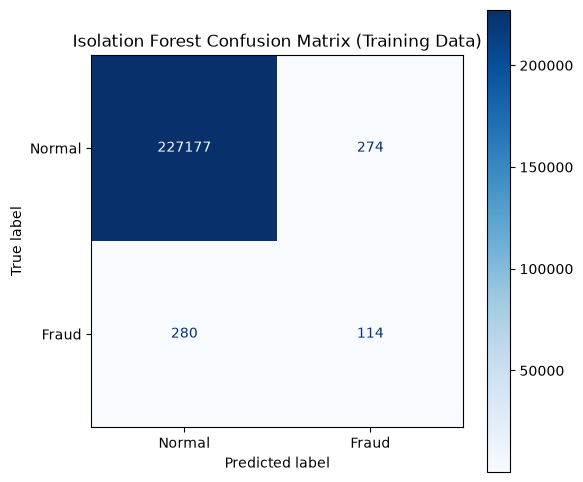

In [21]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Map Isolation Forest predictions to match our true labels
# If prediction is -1 (anomaly), map to 1 (Fraud). Otherwise, map to 0 (Normal).
mapped_train_preds = np.where(train_preds == -1, 1, 0)

# 2. Print Classification Report
print("--- Training Data Evaluation ---")
print(classification_report(y_train, mapped_train_preds, target_names=['Normal (0)', 'Fraud (1)']))

# 3. Plot Confusion Matrix
cm_train = confusion_matrix(y_train, mapped_train_preds)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=['Normal', 'Fraud'])

plt.figure(figsize=(6, 6))
disp_train.plot(cmap='Blues', values_format='d', ax=plt.gca())
plt.title('Isolation Forest Confusion Matrix (Training Data)')
plt.show()

## Evaluating on Testing Data (The True Test)

Now, let's evaluate how our unsupervised Isolation Forest performs on the 20% of data it was completely hidden from during training. This simulates deploying our model into the real world to monitor new, incoming transactions.

In [ ]:
# --- FINAL LAB TASK 4 -- EVALUATE ON THE HELD-OUT TEST SET ---
# 1. Map the Isolation Forest output to match the label convention: it returns -1 for
#    anomaly and 1 for normal, while the labels use 1 for fraud and 0 for normal.
# 2. Print a classification_report for the TEST set.
# 3. Plot the confusion matrix.
#
# Be ready to explain the np.where line rather than just running it.

# YOUR CODE HERE

## Tuning the Contamination Parameter (Precision-Recall Trade-off)

We initially set `contamination=0.0017` because that was the true fraud rate. But in practice, we often set it higher to ensure we don't miss subtle attacks.

Let's test contamination levels ranging from 0.1% up to 5% and see how it affects our ability to catch fraud on the testing set.

In [ ]:
# --- FINAL LAB TASK 5 -- SWEEP CONTAMINATION ---
# 1. Loop over contamination values [0.001, 0.005, 0.01, 0.02, 0.05].
# 2. For each: fit a fresh model, predict on the test set, map the predictions, and record
#    precision and recall for the fraud class.
# 3. Print a row per setting and plot the trade-off.
#
# Before you call any setting 'best', convert its precision into a daily alert volume.

from sklearn.metrics import precision_score, recall_score
import time

# YOUR CODE HERE

**Final Lab write-up.**

1. Report your Isolation Forest's precision, recall and F1 on the **test** set.
2. In **Module 3** you trained supervised models on this exact dataset. Random Forest reached
   an F1 of about **0.87**, and plain logistic regression about **0.72**. Your unsupervised
   model here scores roughly **0.32**. Explain why anyone would ever choose the weaker one.
3. The Isolation Forest never saw a single fraud label during training. Given that, is 0.32
   impressive or disappointing? Argue it either way, but commit to one.
4. Describe a concrete situation in a real security team where the supervised model from
   Module 3 would be unavailable and this one would be your only option.

**[insert response]**

## Final Conclusions: The Reality of Unsupervised Learning

Our hyperparameter tuning revealed a harsh reality of anomaly detection:

*   **To catch the vast majority of fraud (e.g., 87% Recall), we had to increase our contamination to 5%.**
*   **However, at 5% contamination, our Precision plummeted to 3%.**

This means that 97% of the transactions we flagged as "anomalies" were actually perfectly normal customers. In a real-world scenario with millions of transactions, this would overwhelm a Security Operations Center (SOC) with false alarms—a phenomenon known as **Alert Fatigue**.

### So, why use Unsupervised Learning at all?
1.  **The "Zero-Day" Sentinel:** If we had used a *Supervised* model (like a Random Forest) on this data, it would easily achieve 90%+ Precision and Recall because it already knows exactly what fraud looks like. But what happens when the attackers change their tactics tomorrow? The supervised model will miss it. The Isolation Forest, however, is looking for *anything* that breaks the mold of normal behavior. It is our safety net for the unknown.
2.  **Tiered Defense:** In practice, unsupervised models are rarely used in isolation to block transactions. Instead, they are used as one feature among many in a larger, complex security pipeline, or to flag "interesting" cases for human threat hunters to investigate offline.

---

## Where unsupervised learning actually sits

It is worth putting the three modules side by side, because they used **the same dataset** and
the numbers look like a defeat.

| module | approach | saw labels in training? | fraud F1 |
|---|---|---|---|
| 3 | Logistic Regression | yes | ~0.72 |
| 3 | Logistic Regression + tuned threshold | yes | ~0.75 |
| 3 | Random Forest | yes | **~0.87** |
| 4 | **Isolation Forest** | **no** | **~0.32** |

Read naively, unsupervised learning lost badly. That reading misses the only thing that
matters: **the Isolation Forest was never told what fraud is.** It was handed 227,845
transactions with no labels at all, asked to find the odd ones out, and recovered roughly a
third of the fraud in data it had never seen.

The supervised models could only exist because somebody had already labelled 492 frauds by
hand. That labelling is the expensive part, and in security it is frequently impossible:

- **Zero-day attacks** have no labelled examples anywhere, by definition.
- **Insider threats** are rare, contested, and often only confirmed years later.
- **A brand-new deployment** has no incident history to learn from.

In each of those situations the Module 3 models cannot be built at all, and an F1 of 0.32 is
not a poor result — it is the only result.

The practical answer is usually both: unsupervised detection surfaces candidates, analysts
investigate and label them, and those labels eventually train a supervised model. Module 4 is
how that pipeline starts when you have nothing.

---

## Reflection Questions

**1.** You join a company with no labelled security incidents and are asked to build
detection. Describe your first ninety days, using techniques from this module.

**[insert response]**

**2.** Silhouette score needs no labels; precision and recall need them. Explain what each can
and cannot tell you, and why you would want both if you could have them.

**[insert response]**

**3.** Section 10 argues that tuning an unsupervised model on known past attacks partly
defeats its purpose. Do you agree? What would you do instead?

**[insert response]**

**4.** K-Means, DBSCAN, hierarchical clustering and Isolation Forest all found structure in
unlabelled data. Pick two and describe a security problem where one is clearly the right
choice and the other is clearly wrong.

**[insert response]**

**5.** Across Modules 1 to 4 you have now seen a perfect score that meant nothing, a
"strongest predictor" that was a collection artifact, three standard fixes that made a model
worse, and an unsupervised model that looks like a failure and is not. Write the checklist you
would apply to any security-ML result somebody hands you. Between five and eight items.

**[insert response]**